<a href="https://colab.research.google.com/github/Chosencodes/Lung-Segmentation/blob/main/Lung_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install -U gdown
# !gdown https://drive.google.com/file/d/1I1LR7XjyEZ-VBQ-Xruh31V7xExMjlVvi/view?usp=drive_link -O /content/Task06_Lung.tar

In [ ]:
# !tar -xf /content/Task06_Lung.tar -C /content/

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/Task06_Lung '/content/drive/MyDrive/Task06_Lung'

Mounted at /content/drive


In [ ]:
# !du -sh '/content/drive/MyDrive/Task06_Lung'

8.6G	/content/drive/MyDrive/Task06_Lung


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r '/content/drive/MyDrive/Task06_Lung' '/content/Task06_Lung'

data_path = '/content/Task06_Lung'

Mounted at /content/drive


In [ ]:
!ls -la /content/Task06_Lung

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

In [4]:
root = Path("/content/drive/MyDrive/Task06_Lung/imagesTr")
label = Path("/content/drive/MyDrive/Task06_Lung/labelsTr")

In [5]:
sample_path = next(root.glob("lung*.nii.gz"))
sample_label_path = label / sample_path.name

In [8]:
data = nib.load(sample_path)
label = nib.load(sample_label_path)

In [9]:
mri = data.get_fdata()
mask = label.get_fdata().astype(np.uint8)

In [23]:
print(data.shape)
print(label.shape)

print(nib.aff2axcodes(data.affine))
print(nib.aff2axcodes(label.affine))
print(data.header.get_zooms())
print(np.unique(mask))

(512, 512, 252)
(512, 512, 252)
('L', 'A', 'S')
('L', 'A', 'S')
(np.float32(0.9375), np.float32(0.9375), np.float32(1.2450397))
[0 1]


In [24]:
tumor_pixels = np.sum(mask == 1)
background_pixels = np.sum(mask == 0)

print(tumor_pixels)
print(background_pixels)

print("Tumor %:", tumor_pixels / mask.size * 100)

338475
65721813
Tumor %: 0.5123728797549293


In [25]:
tumor_slices = []

for i in range(mask.shape[2]):
    if mask[:, :, i].sum() > 0:
        tumor_slices.append(i)

print("Tumor slices:", len(tumor_slices))
print("First:", tumor_slices[0])
print("Last:", tumor_slices[-1])

Tumor slices: 79
First: 148
Last: 226


In [ ]:
axial_axis = np.argmin(mri.shape)
print("Axial axis is:", axial_axis, "| shape:", mri.shape)

Axial axis is: 2 | shape: (512, 512, 252)


Axial axis: 2 | plotting slice: 181


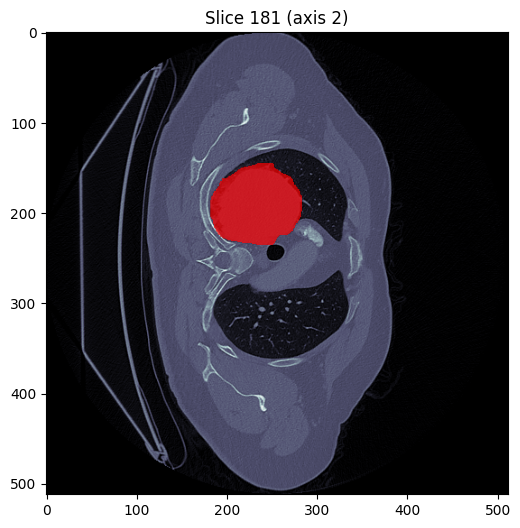

In [ ]:

# use the axial axis you already detected
axial_axis = np.argmin(mri.shape)

# find slices that actually contain tumor, along that axis
other_axes = tuple(i for i in range(3) if i != axial_axis)
tumor_per_slice = mask.sum(axis=other_axes)
tumor_slices = np.where(tumor_per_slice > 0)[0]
slice_num = tumor_slices[np.argmax(tumor_per_slice[tumor_slices])]
print("Axial axis:", axial_axis, "| plotting slice:", slice_num)

# take the slice along whichever axis is axial
img_slice  = np.take(mri,  slice_num, axis=axial_axis)
mask_slice = np.take(mask, slice_num, axis=axial_axis)

plt.figure(figsize=(6, 6))
plt.imshow(img_slice, cmap="bone")
mask_ = np.ma.masked_where(mask_slice == 0, mask_slice)
plt.imshow(mask_, alpha=0.7, cmap="autumn")
plt.title(f"Slice {slice_num} (axis {axial_axis})")
plt.show()

In [ ]:
import os

files = sorted(f for f in os.listdir('/content/Task06_Lung/imagesTr')
               if f.endswith('.nii.gz') and not f.startswith('._'))
print(f"{len(files)} cases found")
print(files[:5])

63 cases found
['lung_001.nii.gz', 'lung_003.nii.gz', 'lung_004.nii.gz', 'lung_005.nii.gz', 'lung_006.nii.gz']


In [ ]:
import os
import nibabel as nib
import numpy as np

def load_case(case_filename, base='/content/Task06_Lung', return_meta=False):
    """Load a NIfTI image volume and its corresponding label mask."""
    img_path = os.path.join(base, 'imagesTr', case_filename)
    lbl_path = os.path.join(base, 'labelsTr', case_filename)

    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")
    if not os.path.exists(lbl_path):
        raise FileNotFoundError(f"Label not found: {lbl_path}")

    image = np.squeeze(nib.load(img_path).get_fdata().astype(np.float32))
    label = np.squeeze(nib.load(lbl_path).get_fdata().astype(np.uint8))

    if image.shape != label.shape:
        raise ValueError(
            f"Shape mismatch for {case_filename}: {image.shape} vs {label.shape}"
        )
    return image, label

Slices containing tumor: [231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248
 250]
Plotting slice: 238


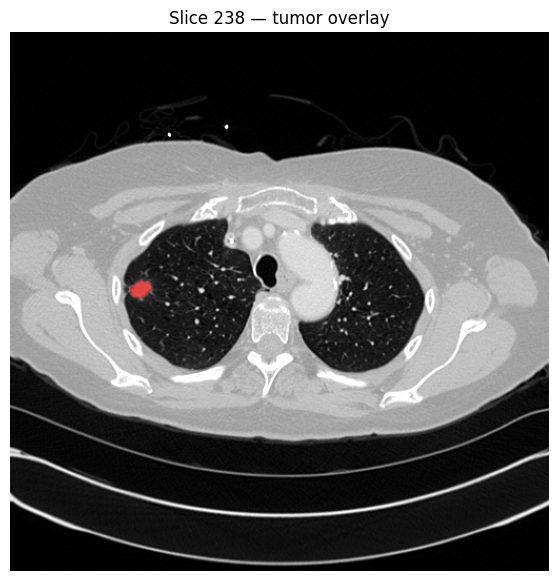

In [ ]:


image, label = load_case(files[0])   # your helper from earlier

# which slices along the depth axis actually contain tumor?
tumor_slices = np.where(label.sum(axis=(0, 1)) > 0)[0]
print("Slices containing tumor:", tumor_slices)

# pick the slice with the most tumor voxels (clearest view)
z = tumor_slices[np.argmax(label.sum(axis=(0, 1))[tumor_slices])]
print("Plotting slice:", z)

img_slice  = image[:, :, z]
mask_slice = label[:, :, z]

# lung window so the CT looks right: clip Hounsfield units, then show
img_windowed = np.clip(img_slice, -1000, 400)

plt.figure(figsize=(7, 7))
plt.imshow(img_windowed.T, cmap="gray", origin="lower")

# overlay ONLY the tumor — hide the zeros so they don't tint the image
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
plt.imshow(mask_overlay.T, alpha=0.6, cmap="autumn", origin="lower")
plt.title(f"Slice {z} — tumor overlay")
plt.axis("off")
plt.show()